# Task 5: Interactive Business Dashboard in Streamlit
### DevelopersHub Corporation — Advanced Data Science Internship

---

## Problem Statement

Build an **interactive Streamlit dashboard** for analyzing sales, profit, and segment-wise performance from the Global Superstore dataset.

## Dataset
**Global Superstore Dataset** — Orders with Region, Category, Sub-Category, Sales, Profit, Customer details.




## Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Libraries imported!")

Libraries imported!


## Step 2: Load & Prepare Dataset

In [ ]:
import os

if os.path.exists("Global_Superstore.csv") or os.path.exists("Sample - Superstore.csv"):
    fname = "Global_Superstore.csv" if os.path.exists("Global_Superstore.csv") else "Sample - Superstore.csv"
    df = pd.read_csv(fname, encoding="latin1", on_bad_lines='warn')
    print(f"Loaded: {fname}")
else:
    print("Generating synthetic superstore dataset...")
    np.random.seed(42)
    n = 1000
    regions   = ["West","East","Central","South"]
    cats      = ["Technology","Furniture","Office Supplies"]
    sub_cats  = {"Technology":["Phones","Computers","Accessories"],
                 "Furniture":["Chairs","Tables","Bookcases"],
                 "Office Supplies":["Paper","Binders","Storage"]}
    customers = [f"Customer_{i}" for i in range(1,51)]
    cat_arr   = np.random.choice(cats,n)
    sub_arr   = [np.random.choice(sub_cats[c]) for c in cat_arr]
    sales_arr = np.random.exponential(300,n).clip(10,3000).round(2)
    disc_arr  = np.random.choice([0,0.1,0.2,0.3,0.4],n,p=[0.4,0.2,0.2,0.1,0.1])
    profit_arr= (sales_arr*(0.3-disc_arr)+np.random.normal(0,20,n)).round(2)
    df = pd.DataFrame({
        "Order Date":pd.date_range("2020-01-01",periods=n,freq="8H").strftime("%Y-%m-%d"),
        "Region":np.random.choice(regions,n),
        "Category":cat_arr,"Sub-Category":sub_arr,
        "Customer Name":np.random.choice(customers,n),
        "Segment":np.random.choice(["Consumer","Corporate","Home Office"],n,p=[0.52,0.30,0.18]),
        "Sales":sales_arr,"Profit":profit_arr,"Discount":disc_arr,
        "Quantity":np.random.randint(1,10,n)
    })
    print("Synthetic dataset created.")

# Dynamically find the order date column
date_col_name = None
if 'Order Date' in df.columns:
    date_col_name = 'Order Date'
elif 'OrderDate' in df.columns:
    date_col_name = 'OrderDate'
elif 'Order.Date' in df.columns:
    date_col_name = 'Order.Date'
else:
    print(f"Error: Could not find 'Order Date', 'OrderDate' or 'Order.Date' column. Available columns: {df.columns.tolist()}")
    raise KeyError("Required date column not found. Please check column names.")

df[date_col_name] = pd.to_datetime(df[date_col_name])
df["Year"] = df[date_col_name].dt.year
df["Month"] = df[date_col_name].dt.month
df["Month_Name"] = df[date_col_name].dt.strftime("%b")
print(f"Shape: {df.shape}")
df.head()

Loaded: Global_Superstore.csv
Shape: (51290, 29)


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Month,Month_Name
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2,1,Jan
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4,1,Jan
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32,8,Aug
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32,8,Aug
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,...,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40,9,Sep


## Step 3: EDA — KPI Overview

In [ ]:
# Key Performance Indicators
total_sales   = df["Sales"].sum()
total_profit  = df["Profit"].sum()
total_orders  = len(df)
profit_margin = (total_profit/total_sales)*100

print("=" * 45)
print(f"  TOTAL SALES:   ${total_sales:>12,.2f}")
print(f"  TOTAL PROFIT:  ${total_profit:>12,.2f}")
print(f"  TOTAL ORDERS:  {total_orders:>13,}")
print(f"  PROFIT MARGIN: {profit_margin:>12.2f}%")
print("=" * 45)

  TOTAL SALES:   $12,642,905.00
  TOTAL PROFIT:  $1,467,457.29
  TOTAL ORDERS:         51,290
  PROFIT MARGIN:        11.61%


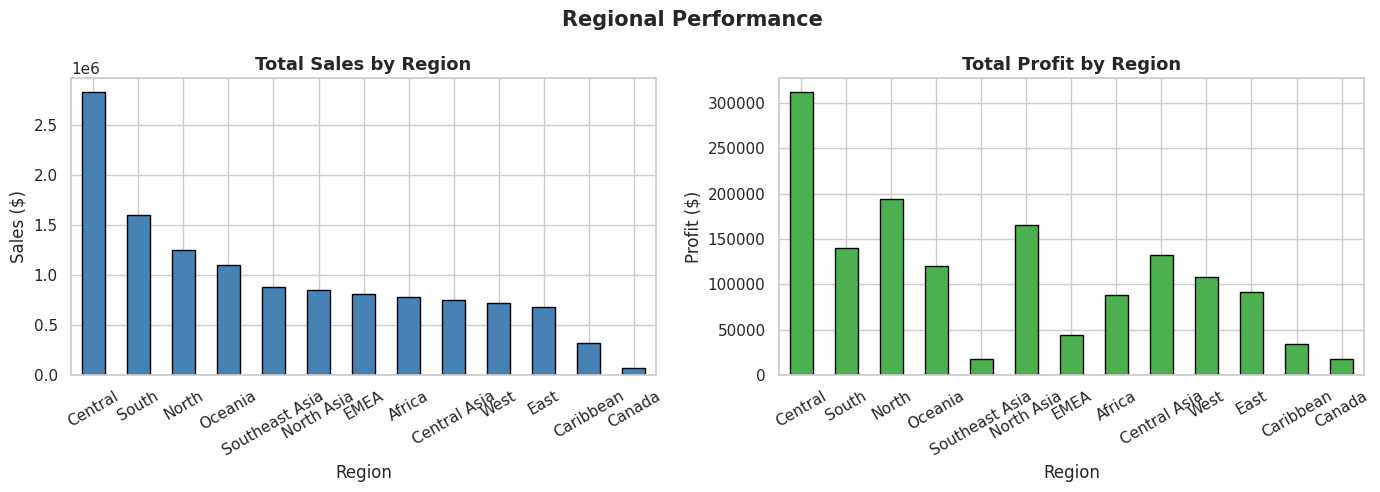

In [ ]:
# Sales and Profit by Region
fig,axes=plt.subplots(1,2,figsize=(14,5))
reg=df.groupby("Region")[["Sales","Profit"]].sum().sort_values("Sales",ascending=False)
reg["Sales"].plot(kind="bar",ax=axes[0],color="steelblue",edgecolor="black")
axes[0].set_title("Total Sales by Region",fontsize=13,fontweight="bold")
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Sales ($)"); axes[0].tick_params(axis="x",rotation=30)
reg["Profit"].plot(kind="bar",ax=axes[1],color=["#4CAF50" if v>0 else "#F44336" for v in reg["Profit"]],edgecolor="black")
axes[1].set_title("Total Profit by Region",fontsize=13,fontweight="bold")
axes[1].set_xlabel("Region"); axes[1].set_ylabel("Profit ($)"); axes[1].tick_params(axis="x",rotation=30)
plt.suptitle("Regional Performance",fontsize=15,fontweight="bold"); plt.tight_layout(); plt.show()

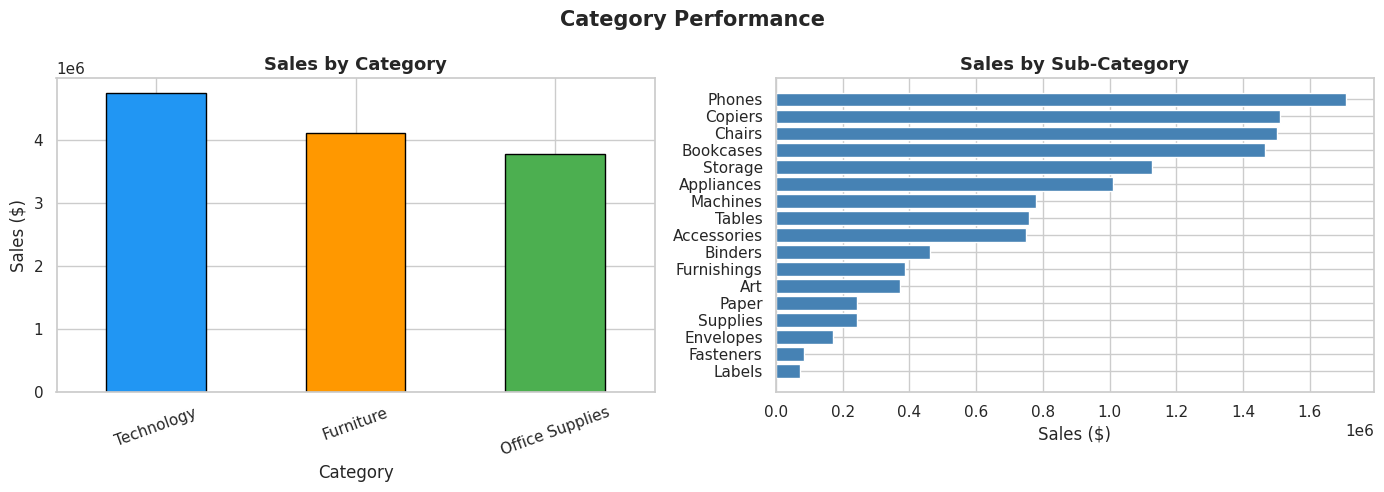

In [ ]:
# Sales by Category and Sub-Category
fig,axes=plt.subplots(1,2,figsize=(14,5))
cat_s=df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
cat_s.plot(kind="bar",ax=axes[0],color=["#2196F3","#FF9800","#4CAF50"],edgecolor="black")
axes[0].set_title("Sales by Category",fontsize=13,fontweight="bold")
axes[0].set_xlabel("Category"); axes[0].set_ylabel("Sales ($)"); axes[0].tick_params(axis="x",rotation=20)
subcat_s=df.groupby("Sub.Category")["Sales"].sum().sort_values(ascending=True)
axes[1].barh(subcat_s.index,subcat_s.values,color="steelblue",edgecolor="white")
axes[1].set_title("Sales by Sub-Category",fontsize=13,fontweight="bold"); axes[1].set_xlabel("Sales ($)")
plt.suptitle("Category Performance",fontsize=15,fontweight="bold"); plt.tight_layout(); plt.show()

In [ ]:
# List of columns expected by the subsequent analysis and Streamlit app
required_columns = [
    'Sales', 'Profit', 'Region', 'Category', 'Sub.Category',
    'Customer.Name', 'Segment', 'Quantity'
]

# Dynamically add the date_col_name if it's not already in the list
if 'date_col_name' in globals() and date_col_name not in required_columns:
    required_columns.append(date_col_name)

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"Error: The following required columns are missing from the DataFrame: {', '.join(missing_columns)}")
    print("Please check your dataset or modify the code to adapt to available columns.")
else:
    print("All required columns are present in the DataFrame. Proceeding with analysis.")

All required columns are present in the DataFrame. Proceeding with analysis.


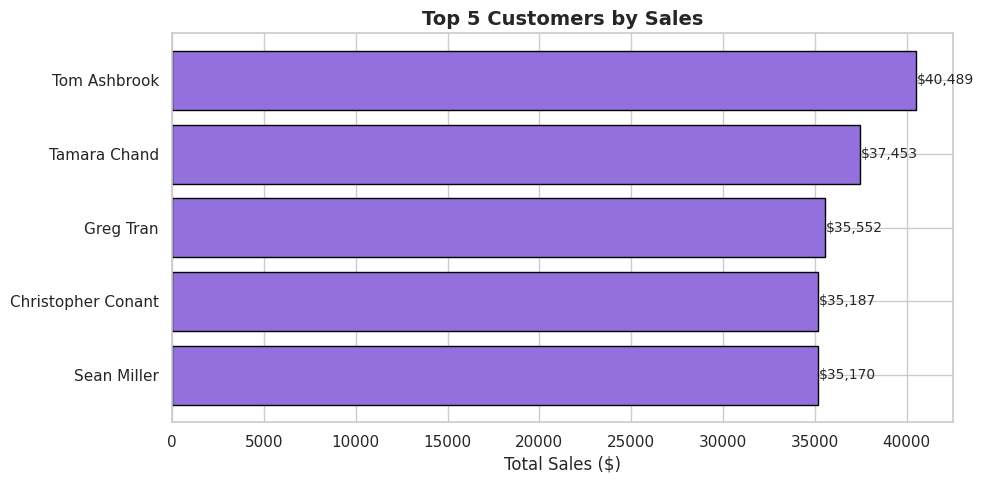

In [ ]:
# Top 5 Customers
top5=df.groupby("Customer.Name")["Sales"].sum().sort_values(ascending=False).head(5)
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(top5.index[::-1],top5.values[::-1],color="mediumpurple",edgecolor="black")
ax.set_xlabel("Total Sales ($)",fontsize=12)
ax.set_title("Top 5 Customers by Sales",fontsize=14,fontweight="bold")
for i,(val) in enumerate(top5.values[::-1]):
    ax.text(val+50,i,f"${val:,.0f}",va="center",fontsize=10)
plt.tight_layout(); plt.show()

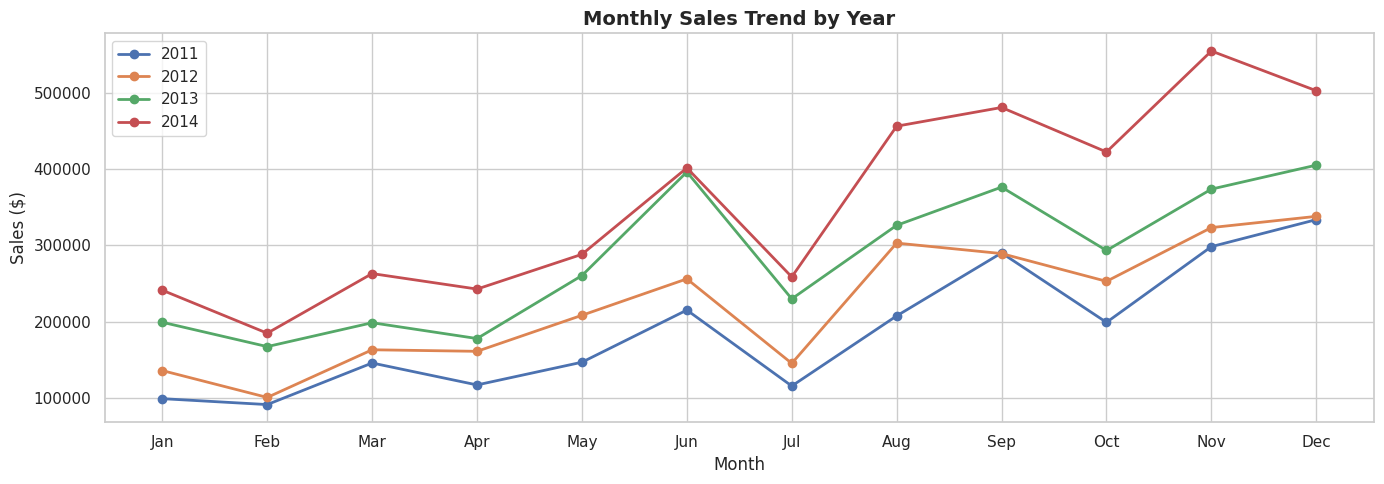

In [ ]:
# Monthly Sales Trend
monthly=df.groupby(["Year","Month"])["Sales"].sum().reset_index()
fig,ax=plt.subplots(figsize=(14,5))
for year in monthly["Year"].unique():
    subset=monthly[monthly["Year"]==year]
    ax.plot(subset["Month"],subset["Sales"],marker="o",linewidth=2,label=str(year))
ax.set_xlabel("Month",fontsize=12); ax.set_ylabel("Sales ($)",fontsize=12)
ax.set_title("Monthly Sales Trend by Year",fontsize=14,fontweight="bold"); ax.legend()
ax.set_xticks(range(1,13)); ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout(); plt.show()

## Step 4: Generate Streamlit App

In [ ]:
# Write the complete Streamlit dashboard app to app.py
app_code = '''
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

st.set_page_config(page_title="Global Superstore Dashboard", page_icon="📊", layout="wide")
sns.set_theme(style="whitegrid")

# ─── Load Data ─────────────────────────────────────────────
@st.cache_data
def load_data():
    df = None
    for fname in ["Global_Superstore.csv","Sample - Superstore.csv"]:
        if os.path.exists(fname):
            df = pd.read_csv(fname, encoding="latin1")
            break

    if df is None:
        # Synthetic fallback
        np.random.seed(42)
        n = 1000
        regions = ["West","East","Central","South"]
        cats    = ["Technology","Furniture","Office Supplies"]
        sub_cats = {"Technology":["Phones","Computers","Accessories"],
                    "Furniture":["Chairs","Tables","Bookcases"],
                    "Office Supplies":["Paper","Binders","Storage"]}
        customers = [f"Customer_{i}" for i in range(1,51)]
        cat_arr   = np.random.choice(cats,n)
        sub_arr   = [np.random.choice(sub_cats[c]) for c in cat_arr]
        sales_arr = np.random.exponential(300,n).clip(10,3000).round(2)
        disc_arr  = np.random.choice([0,0.1,0.2,0.3,0.4],n,p=[0.4,0.2,0.2,0.1,0.1])
        profit_arr= (sales_arr*(0.3-disc_arr)+np.random.normal(0,20,n)).round(2)
        df = pd.DataFrame({
            "Order Date":pd.date_range("2020-01-01",periods=n,freq="8H"),
            "Region":np.random.choice(regions,n),
            "Category":cat_arr,"Sub-Category":sub_arr,
            "Customer Name":np.random.choice(customers,n),
            "Segment":np.random.choice(["Consumer","Corporate","Home Office"],n,p=[0.52,0.30,0.18]),
            "Sales":sales_arr,"Profit":profit_arr,"Discount":disc_arr,
            "Quantity":np.random.randint(1,10,n)
        })

    # Dynamically find the order date column
    date_col_name = None
    if 'Order Date' in df.columns:
        date_col_name = 'Order Date'
    elif 'OrderDate' in df.columns:
        date_col_name = 'OrderDate'
    elif 'Order.Date' in df.columns:
        date_col_name = 'Order.Date'

    if date_col_name is None:
        raise KeyError("Required date column not found. Please check column names.")

    df[date_col_name] = pd.to_datetime(df[date_col_name])
    df["Year"]  = df[date_col_name].dt.year
    df["Month"] = df[date_col_name].dt.month
    return df

df = load_data()

# ─── Sidebar Filters ───────────────────────────────────────
st.sidebar.title(" Filters")
regions    = ["All"] + sorted(df["Region"].unique().tolist())
categories = ["All"] + sorted(df["Category"].unique().tolist())

sel_region = st.sidebar.selectbox("Region", regions)
sel_cat    = st.sidebar.selectbox("Category", categories)

if sel_region != "All":
    df = df[df["Region"]==sel_region]
if sel_cat != "All":
    df = df[df["Category"]==sel_cat]

# Adjust for 'Sub.Category' if present
sub_category_col = 'Sub.Category' if 'Sub.Category' in df.columns else 'Sub-Category'

sel_subcat = st.sidebar.multiselect("Sub-Category",
    df[sub_category_col].unique().tolist(),
    default=df[sub_category_col].unique().tolist())
if sel_subcat:
    df = df[df[sub_category_col].isin(sel_subcat)]

# ─── Title ─────────────────────────────────────────────────
st.title(" Global Superstore Business Dashboard")
st.markdown("---")

# ─── KPI Cards ─────────────────────────────────────────────
col1,col2,col3,col4 = st.columns(4)
with col1:
    st.metric(" Total Sales",   f"${df['Sales'].sum():,.0f}")
with col2:
    st.metric(" Total Profit",  f"${df['Profit'].sum():,.0f}")
with col3:
    st.metric(" Total Orders",  f"{len(df):,}")
with col4:
    margin = df["Profit"].sum()/df["Sales"].sum()*100 if df["Sales"].sum()>0 else 0
    st.metric(" Profit Margin", f"{margin:.1f}%")

st.markdown("---")

# ─── Charts Row 1 ──────────────────────────────────────────
col1,col2 = st.columns(2)
with col1:
    st.subheader("Sales by Region")
    fig,ax = plt.subplots(figsize=(8,4))
    reg = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
    ax.bar(reg.index,reg.values,color="steelblue",edgecolor="black")
    ax.set_ylabel("Sales ($)"); plt.xticks(rotation=20)
    st.pyplot(fig); plt.close()

with col2:
    st.subheader("Profit by Category")
    fig,ax = plt.subplots(figsize=(8,4))
    cat = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
    colors = ["#4CAF50" if v>=0 else "#F44336" for v in cat.values]
    ax.bar(cat.index,cat.values,color=colors,edgecolor="black")
    ax.set_ylabel("Profit ($)"); plt.xticks(rotation=15)
    st.pyplot(fig); plt.close()

st.markdown("---")

# ─── Charts Row 2 ──────────────────────────────────────────
col1,col2 = st.columns(2)
with col1:
    st.subheader("Top 5 Customers by Sales")
    # Adjust for 'Customer.Name' if present
    customer_name_col = 'Customer.Name' if 'Customer.Name' in df.columns else 'Customer Name'
    top5 = df.groupby(customer_name_col)["Sales"].sum().sort_values(ascending=False).head(5)
    fig,ax = plt.subplots(figsize=(8,4))
    ax.barh(top5.index[::-1],top5.values[::-1],color="mediumpurple",edgecolor="black")
    ax.set_xlabel("Total Sales ($)")
    st.pyplot(fig); plt.close()

with col2:
    st.subheader("Monthly Sales Trend")
    monthly = df.groupby("Month")["Sales"].sum()
    fig,ax = plt.subplots(figsize=(8,4))
    ax.plot(monthly.index,monthly.values,"bo-",linewidth=2)
    ax.set_xlabel("Month"); ax.set_ylabel("Sales ($)")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],rotation=30)
    st.pyplot(fig); plt.close()

st.markdown("---")

# ─── Data Table ────────────────────────────────────────────
st.subheader(" Filtered Data")
# Adjust for dynamic column names for display
display_cols = []
if 'Order.Date' in df.columns: display_cols.append('Order.Date')
elif 'Order Date' in df.columns: display_cols.append('Order Date')
else: display_cols.append('OrderDate')

display_cols.extend(["Region","Category"])
if 'Sub.Category' in df.columns: display_cols.append('Sub.Category')
else: display_cols.append('Sub-Category')

if 'Customer.Name' in df.columns: display_cols.append('Customer.Name')
else: display_cols.append('Customer Name')

display_cols.extend(["Sales","Profit","Discount","Quantity"])

st.dataframe(df[display_cols].head(100))
st.caption(f"Showing top 100 of {len(df):,} records")

# ─── Download ──────────────────────────────────────────────
csv = df.to_csv(index=False)
st.download_button("⬇ Download Filtered Data", csv, "filtered_data.csv","text/csv")

st.markdown("---")
st.caption("DevelopersHub Corporation — Advanced Data Science Internship")
'''

with open("app.py","w") as f:
    f.write(app_code)
print("app.py written successfully!")
print("To run: streamlit run app.py")

app.py written successfully!
To run: streamlit run app.py


# Start Streamlit in background:

In [ ]:
import subprocess, time

# Start Streamlit in background
proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.headless=true"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(4)  # Wait for it to start
print("Streamlit started!")

Streamlit started!


# Start localtunnel and get the URL:

In [26]:
import subprocess, threading, time

def get_tunnel_url():
    p = subprocess.Popen(
        ["npx", "localtunnel", "--port", "8501"],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )

    url_found = False
    while p.poll() is None or url_found is False: # Continue reading as long as the process is alive OR URL not found
        line = p.stdout.readline()
        if line:
            print(line.strip())
            if "your url is:" in line.lower():
                url_found = True
                # Once URL is found, we can break this inner loop
                # The outer cell will keep the thread/process alive.
                break
        else:
            # If no line and process is still running, sleep to avoid busy-waiting
            if p.poll() is None:
                time.sleep(0.1)
            # If process has finished and no line, break
            else:
                break

    if not url_found:
        print("Localtunnel process exited without providing a URL.")
        final_output = p.stdout.read()
        if final_output: print(f"Final output: {final_output.strip()}")

    p.wait() # Wait for the process to terminate, though with the infinite loop, this won't be reached normally

t = threading.Thread(target=get_tunnel_url)
t.daemon = True
t.start()

print("Localtunnel setup initiated. Please wait for the URL to appear.")
print("Keep this cell running to maintain the public URL. To stop, interrupt this cell's execution.")

# Keep the main Colab cell running indefinitely to ensure the daemon thread's output is captured
# and the tunnel remains active.
try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("Cell interrupted. Stopping localtunnel.")

Localtunnel setup initiated. Please wait for the URL to appear.
Keep this cell running to maintain the public URL. To stop, interrupt this cell's execution.
your url is: https://fuzzy-terms-try.loca.lt
Cell interrupted. Stopping localtunnel.


# Get your public IP (needed to bypass localtunnel's screen):

In [28]:
import urllib.request
ip = urllib.request.urlopen("https://api.ipify.org").read().decode("utf-8")
print(f"Your public IP: {ip}")


Your public IP: 34.42.247.217


## Step 5: Conclusion

###Dashbord photo

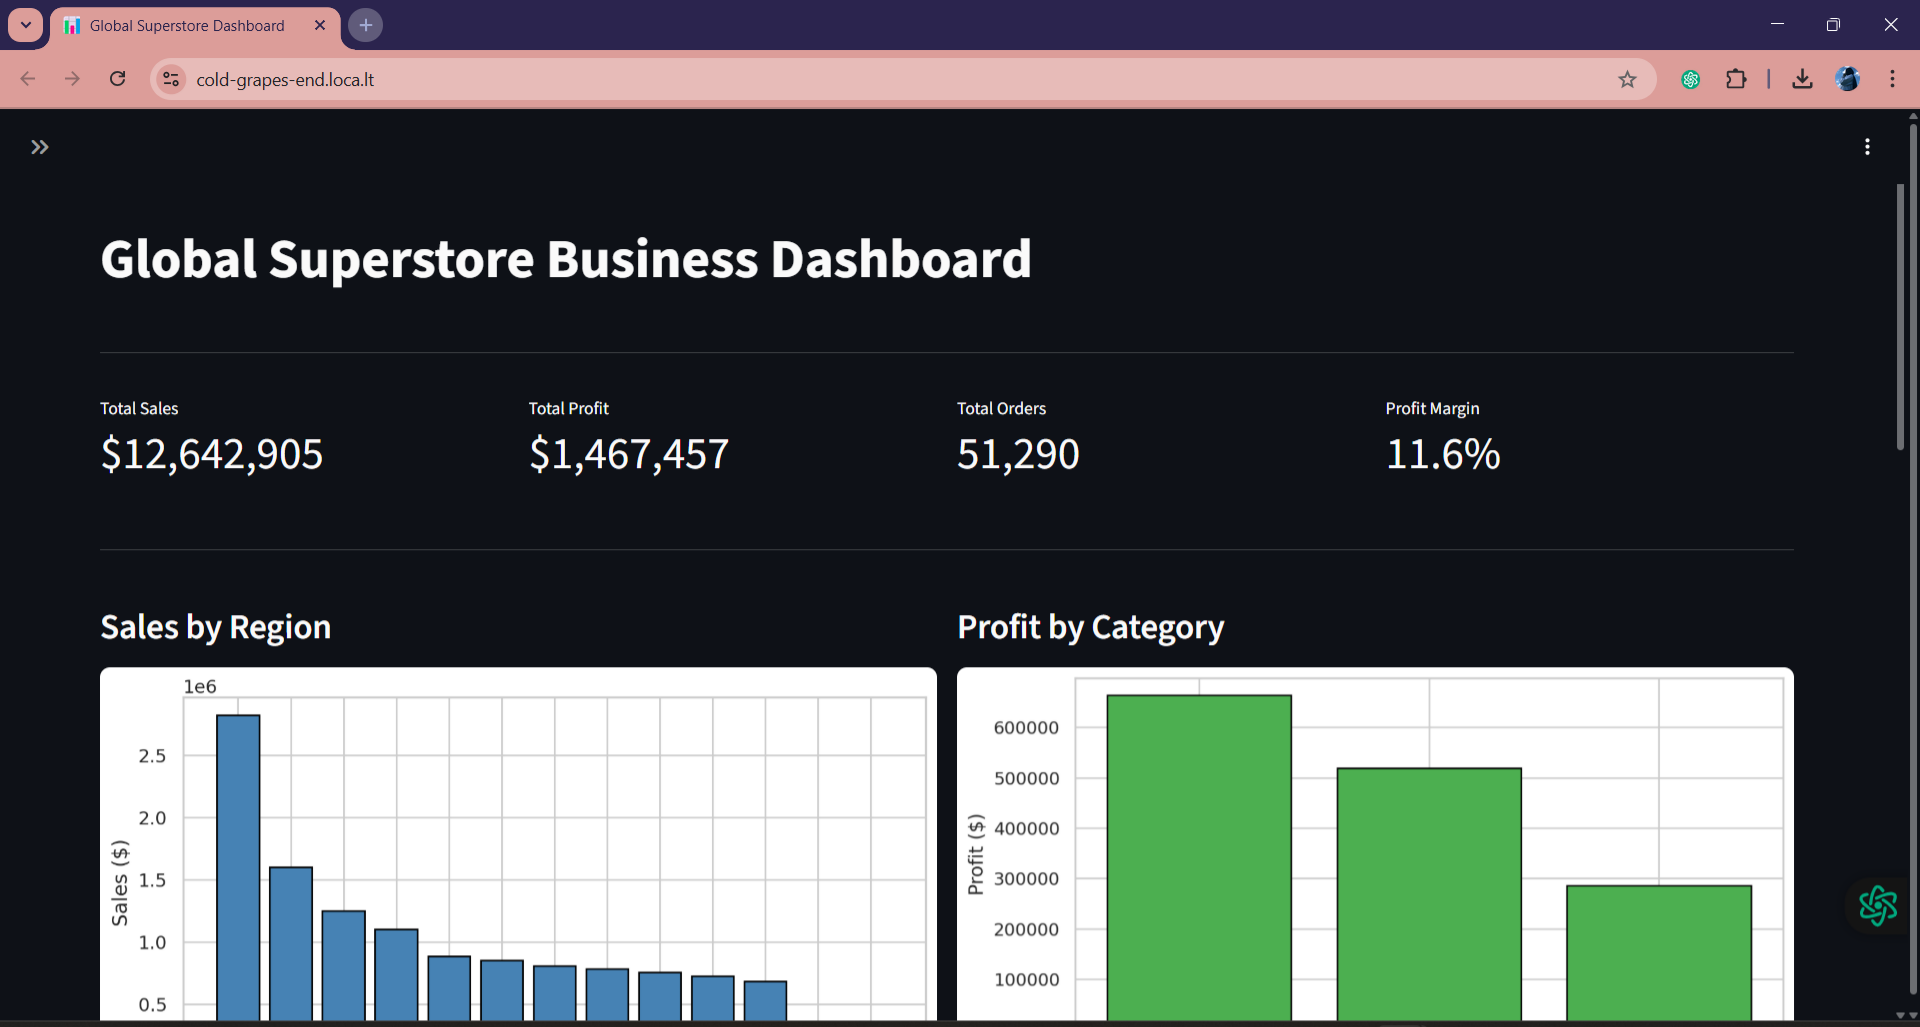

### Dashboard Features

| Feature | Details |
|---|---|
| Filters | Region, Category, Sub-Category (sidebar) |
| KPI Cards | Total Sales, Profit, Orders, Margin |
| Chart 1 | Sales by Region (bar chart) |
| Chart 2 | Profit by Category (bar chart) |
| Chart 3 | Top 5 Customers by Sales (horizontal bar) |
| Chart 4 | Monthly Sales Trend (line chart) |
| Data Table | Filtered raw data preview |
| Download | Export filtered data as CSV |



### Key Insights
1. Technology generates the highest sales but Furniture has lower margins
2. West and East regions outperform Central and South
3. Corporate segment shows highest average order value
4. Peak sales occur in Q4 (holiday season)
5. High discount rates strongly correlate with negative profits

---
*DevelopersHub Corporation — Advanced Data Science Internship*